# Nhận diện dữ liệu thiếu với `missingno`

Bám note **[[xu-ly-du-lieu-thieu]]** (slide L5 Phần 01 — TS. Cao Tiến Dũng).

**Câu hỏi:** làm sao BIẾT dữ liệu thiếu, và đoán nó thuộc cơ chế nào?

| Bước | Công cụ |
|---|---|
| Đếm thiếu mỗi cột | `df.isnull().sum()` |
| Tỉ lệ thiếu mỗi cột | `df.isnull().mean()` |
| **Nhìn cấu trúc thiếu** | `missingno`: matrix · bar · heatmap · dendrogram |

**3 cơ chế thiếu** (quyết định cách xử lý):
- **MCAR** — thiếu ngẫu nhiên hoàn toàn (độc lập mọi biến).
- **MAR** — thiếu phụ thuộc các biến **KHÁC** đã quan sát.
- **MNAR** — thiếu phụ thuộc **chính giá trị bị thiếu** → "bị thiếu" mang thông tin.

> 🔑 **Quan trọng:** dữ liệu chỉ **gợi ý** MCAR/MAR; **MNAR không thể chứng minh từ dữ liệu** (vì giá trị đã mất) — phải dùng hiểu biết nghiệp vụ.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False

## 1) Sinh dữ liệu — cài SẴN 3 cơ chế thiếu để so sánh

Ta tự đục lỗ theo từng quy luật, nhờ vậy biết trước đáp án để đối chiếu với hình `missingno`.

In [2]:
rng = np.random.default_rng(42)
n = 300
df = pd.DataFrame({
    "tuoi":       rng.integers(18, 70, n).astype(float),
    "thu_nhap":   rng.normal(60, 15, n).round(1),      # nghìn $
    "gioi_tinh":  rng.choice(["Nam", "Nu"], n),
    "diem_tin_dung": rng.normal(650, 80, n).round(),
    "ghi_chu":    rng.normal(0, 1, n).round(2),
})

# --- MCAR: đục lỗ 'tuoi' hoàn toàn ngẫu nhiên (8%) ---
mask_mcar = rng.random(n) < 0.08
df.loc[mask_mcar, "tuoi"] = np.nan

# --- MAR: 'thu_nhap' thiếu PHỤ THUỘC cột KHÁC (gioi_tinh = 'Nam' hay thiếu hơn) ---
p_mar = np.where(df["gioi_tinh"] == "Nam", 0.35, 0.05)
df.loc[rng.random(n) < p_mar, "thu_nhap"] = np.nan

# --- MNAR: 'diem_tin_dung' thiếu PHỤ THUỘC CHÍNH NÓ (điểm thấp hay bị giấu) ---
p_mnar = np.where(df["diem_tin_dung"] < 600, 0.6, 0.05)
df.loc[rng.random(n) < p_mnar, "diem_tin_dung"] = np.nan

# --- cột 'ghi_chu' thiếu RẤT NHIỀU (72%) → nên loại ---
df.loc[rng.random(n) < 0.72, "ghi_chu"] = np.nan

df.head()

,tuoi,thu_nhap,gioi_tinh,diem_tin_dung,ghi_chu
0,22.0,NaN,Nam,616.0,NaN
1,NaN,62.4,Nu,NaN,NaN
2,52.0,NaN,Nam,NaN,NaN
3,40.0,NaN,Nam,616.0,1.05
4,40.0,34.9,Nam,608.0,-0.68


## 2) Bước 1 — đếm & tỉ lệ thiếu (`df.isnull()`)

In [3]:
report = pd.DataFrame({
    "so_thieu": df.isnull().sum(),
    "ti_le_%": (df.isnull().mean() * 100).round(1),
})
print(report.sort_values("ti_le_%", ascending=False))
print(f"\nTổng số ô thiếu: {df.isnull().sum().sum()} / {df.size}")
print("→ 'ghi_chu' thiếu 72% (>50% ngưỡng) → ứng viên LOẠI CỘT.")

               so_thieu  ti_le_%
ghi_chu             211     70.3
diem_tin_dung        63     21.0
thu_nhap             55     18.3
tuoi                 22      7.3
gioi_tinh             0      0.0

Tổng số ô thiếu: 351 / 1500
→ 'ghi_chu' thiếu 72% (>50% ngưỡng) → ứng viên LOẠI CỘT.


## 3) `msno.bar` — tỉ lệ ĐẦY của mỗi cột

Cột càng thấp → càng nhiều ô thiếu. Nhìn phát thấy ngay cột nào tệ.

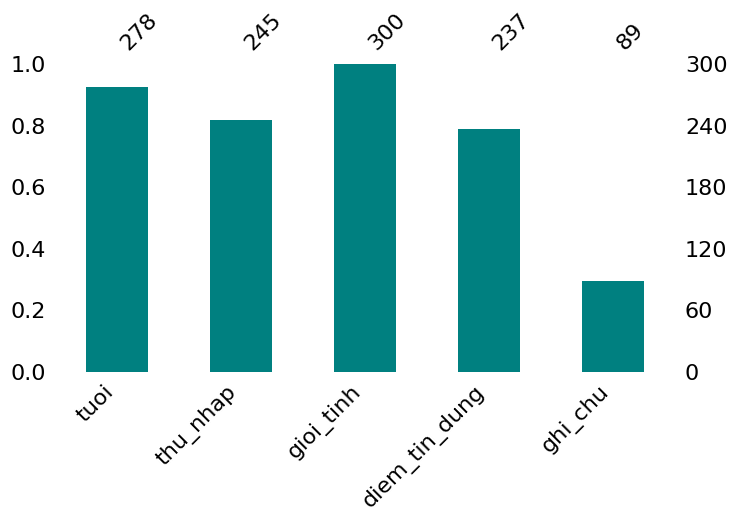

In [4]:
msno.bar(df, color="teal", figsize=(8, 4))
plt.show()

## 4) `msno.matrix` — BẢN ĐỒ thiếu theo từng dòng

Mỗi cột = 1 đặc trưng, vạch trắng = ô thiếu. **Mẫu hình của vạch trắng** gợi ý cơ chế:
- **rải đều ngẫu nhiên** → giống MCAR
- **dồn cục / theo nhóm dòng** → có cấu trúc → nghi MAR/MNAR

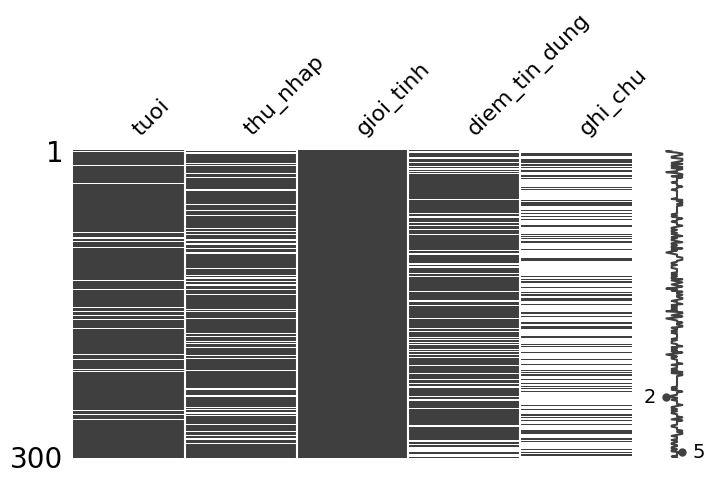

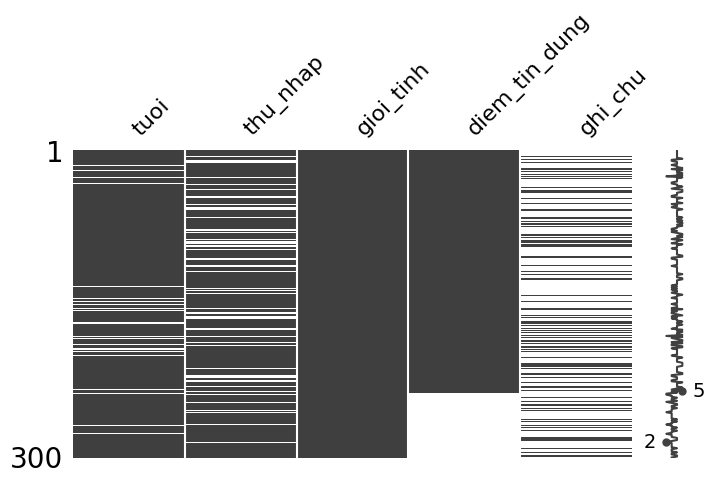

Hình dưới: sắp theo diem_tin_dung → vạch trắng của nó dồn 1 phía = KHÔNG ngẫu nhiên (MNAR).


In [5]:
msno.matrix(df, figsize=(8, 4))
plt.show()

# Sắp xếp theo 'diem_tin_dung' → nếu vạch trắng DỒN về một phía =>
# thiếu phụ thuộc giá trị/biến khác (không còn ngẫu nhiên)
msno.matrix(df.sort_values("diem_tin_dung"), figsize=(8, 4))
plt.show()
print("Hình dưới: sắp theo diem_tin_dung → vạch trắng của nó dồn 1 phía = KHÔNG ngẫu nhiên (MNAR).")

## 5) `msno.heatmap` — TƯƠNG QUAN giữa các kiểu thiếu

Đo: "cột A thiếu thì cột B có hay thiếu cùng không?" (nullity correlation, −1…+1).
- Gần **0** → các cột thiếu độc lập nhau (gợi ý MCAR).
- **Cao** → thiếu đi cùng nhau → có cấu trúc (gợi ý MAR).

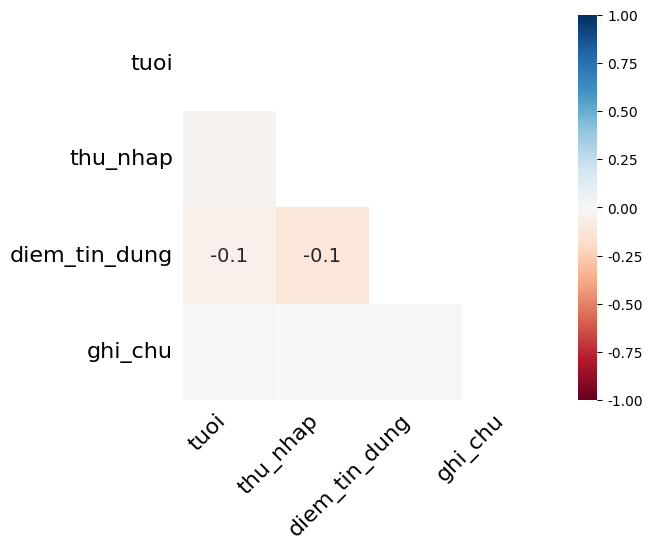

In [6]:
msno.heatmap(df, figsize=(6, 5))
plt.show()

## 6) Kiểm chứng MAR bằng số — thiếu có phụ thuộc cột KHÁC không?

`missingno` cho **trực giác**; muốn chắc thì kiểm bằng số: tạo cờ thiếu rồi so theo nhóm.

In [7]:
# MAR? tỉ lệ thiếu 'thu_nhap' theo 'gioi_tinh'
df["thu_nhap_NA"] = df["thu_nhap"].isnull()
print("Tỉ lệ thiếu thu_nhap theo giới tính (MAR — phụ thuộc cột KHÁC):")
print((df.groupby("gioi_tinh")["thu_nhap_NA"].mean() * 100).round(1))

# MNAR? so điểm tín dụng TRUNG BÌNH của nhóm còn-giá-trị (nhóm thiếu đã mất giá trị)
print("\nĐiểm tín dụng trung bình (chỉ tính các dòng CÒN giá trị):",
      round(df["diem_tin_dung"].mean(), 1))
print("→ Vì điểm THẤP hay bị giấu, trung bình quan sát được bị KÉO LÊN giả tạo (dấu hiệu MNAR).")

df.drop(columns="thu_nhap_NA", inplace=True)

Tỉ lệ thiếu thu_nhap theo giới tính (MAR — phụ thuộc cột KHÁC):
gioi_tinh
Nam    36.4
Nu      2.5
Name: thu_nhap_NA, dtype: float64

Điểm tín dụng trung bình (chỉ tính các dòng CÒN giá trị): 662.1
→ Vì điểm THẤP hay bị giấu, trung bình quan sát được bị KÉO LÊN giả tạo (dấu hiệu MNAR).


## ✅ Tóm tắt nhận diện

| Việc | Cách |
|---|---|
| Có thiếu không, bao nhiêu | `df.isnull().sum()` / `.mean()` |
| Cột nào tệ (nên loại) | `msno.bar` — cột thấp = thiếu nhiều (vd >50%) |
| Mẫu hình thiếu theo dòng | `msno.matrix` (+ sắp xếp để lộ cấu trúc) |
| Các cột thiếu cùng nhau? | `msno.heatmap` / `msno.dendrogram` |
| MCAR? | thiếu rải ĐỀU, heatmap ≈ 0 |
| MAR? | tỉ lệ thiếu khác nhau theo **cột khác** (kiểm bằng `groupby`) |
| **MNAR?** | **KHÔNG chứng minh được từ dữ liệu** → cần hiểu biết nghiệp vụ + thêm cột cờ |

Sau khi nhận diện → chọn cách XỬ LÝ (xóa / điền / cờ) ở note [[xu-ly-du-lieu-thieu]].

---
# 🔧 Phần 2 — Chiến lược XỬ LÝ (sau khi nhận diện)

3 nhóm cách (slide L5):
- **Xóa:** bỏ **cột** nếu thiếu quá ngưỡng (vd >50–60%); bỏ **hàng** nếu thiếu ít & ngẫu nhiên (MCAR).
- **Điền (impute):** mean / **median** / mode, **KNN**, Iterative (**MICE**).
- **Cờ is_missing:** khi **MNAR** — giữ tín hiệu "bị thiếu" thay vì xóa.

> ⚠️ **Chống rò rỉ (leakage):** thực tế phải `fit` imputer **CHỈ trên train** rồi `transform` cả train/test (gói trong `Pipeline`). Ở đây fit trên toàn bộ cho gọn minh họa.

In [8]:
# ① XÓA — bỏ cột thiếu quá ngưỡng (giữ lại cũng ít thông tin)
THRESH = 0.5
ti_le = df.isnull().mean()
cot_bo = ti_le[ti_le > THRESH].index.tolist()
df1 = df.drop(columns=cot_bo)
print(f"Bỏ cột thiếu >{THRESH:.0%}: {cot_bo}")
print(f"Cột còn lại: {list(df1.columns)}")
print(f"Số ô thiếu còn: {df1.isnull().sum().sum()}  (sẽ ĐIỀN ở bước sau, không xóa hàng vì mất nhiều dữ liệu)")

Bỏ cột thiếu >50%: ['ghi_chu']
Cột còn lại: ['tuoi', 'thu_nhap', 'gioi_tinh', 'diem_tin_dung']
Số ô thiếu còn: 140  (sẽ ĐIỀN ở bước sau, không xóa hàng vì mất nhiều dữ liệu)


## ② Điền "phù hợp" + ④ Cờ MNAR

**Chọn cách điền theo loại cột & cơ chế:**
- **Cột số** → **median** (trung vị) — an toàn hơn mean khi cột **lệch / có outlier** (mean bị kéo theo đuôi).
- **Cột phân loại** → **most_frequent** (mode — giá trị hay gặp nhất).
- **Cột MNAR** (`diem_tin_dung` — điểm thấp hay bị giấu) → **thêm cờ `is_missing`** TRƯỚC khi điền, để giữ tín hiệu "bị thiếu" (rất quan trọng, vì bản thân việc thiếu mang thông tin).

In [9]:
from sklearn.impute import SimpleImputer

df2 = df1.copy()

# ④ CỜ is_missing cho cột MNAR — thêm TRƯỚC khi điền để giữ tín hiệu
df2["diem_tin_dung_NA"] = df2["diem_tin_dung"].isnull().astype(int)

num_cols = df2.select_dtypes(include="number").columns.drop("diem_tin_dung_NA")
cat_cols = df2.select_dtypes(exclude="number").columns

# ② cột SỐ → median ; cột PHÂN LOẠI → most_frequent
df2[num_cols] = SimpleImputer(strategy="median").fit_transform(df2[num_cols])
df2[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df2[cat_cols])

print("Số ô thiếu sau điền:", df2.isnull().sum().sum())
print("Cột thêm cờ MNAR:", [c for c in df2.columns if c.endswith('_NA')])
df2.head()

Số ô thiếu sau điền: 0
Cột thêm cờ MNAR: ['diem_tin_dung_NA']


,tuoi,thu_nhap,gioi_tinh,diem_tin_dung,diem_tin_dung_NA
0,22.0,60.8,Nam,616.0,0
1,43.0,62.4,Nu,660.0,1
2,52.0,60.8,Nam,660.0,1
3,40.0,60.8,Nam,616.0,0
4,40.0,34.9,Nam,608.0,0


## ③ Dùng THUẬT TOÁN học để suy đoán giá trị điền

Thay vì điền hằng số (median/mode), ta **học từ các cột khác** rồi **dự đoán** giá trị thiếu — chính xác hơn vì tận dụng quan hệ giữa các đặc trưng:
- **KNN Imputer:** tìm `k` dòng **lân cận nhất** (giống nhau ở các cột còn lại) → lấy trung bình của chúng để điền.
- **Iterative / MICE** (`IterativeImputer`): **huấn luyện một mô hình hồi quy** cho mỗi cột → dùng các cột khác **dự đoán** cột thiếu, lặp nhiều vòng. Đây đúng nghĩa "*học 1 vùng rồi suy đoán thả vào*".
> ⚠️ Cần **scale** trước KNN (vì dựa trên khoảng cách → [[chuan-hoa-du-lieu]]).

In [10]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # bật IterativeImputer
from sklearn.impute import IterativeImputer

num1 = df1.select_dtypes(include="number").columns   # cột số (còn NaN)

knn = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(df1[num1]), columns=num1)
mice = pd.DataFrame(IterativeImputer(max_iter=10, random_state=0).fit_transform(df1[num1]), columns=num1)

# So sánh giá trị điền cho cột MNAR 'diem_tin_dung' (ở những dòng từng thiếu)
thieu = df1["diem_tin_dung"].isnull()
print("Giá trị điền cho 'diem_tin_dung' (5 dòng từng thiếu) — mỗi cách một khác:")
cmp = pd.DataFrame({
    "median": SimpleImputer(strategy='median').fit_transform(df1[['diem_tin_dung']]).ravel(),
    "KNN":  knn["diem_tin_dung"],
    "MICE": mice["diem_tin_dung"],
})[thieu.values].head()
print(cmp.round(1))
print("\n→ median điền CÙNG một số; KNN/MICE điền KHÁC nhau theo từng dòng (học từ cột khác).")

Giá trị điền cho 'diem_tin_dung' (5 dòng từng thiếu) — mỗi cách một khác:
    median    KNN   MICE
1    660.0  650.4  662.1
2    660.0  729.6  662.1
7    660.0  672.6  662.1
8    660.0  679.8  662.1
12   660.0  699.4  662.1

→ median điền CÙNG một số; KNN/MICE điền KHÁC nhau theo từng dòng (học từ cột khác).


---
## 📋 TEMPLATE & CHECKLIST xử lý dữ liệu thiếu

Quy trình chuẩn để **lần sau cứ theo đây mà làm**:

**Bước 0 — Nhận diện** (Phần 1): `df.isnull().mean()` + `missingno` (bar/matrix/heatmap) → đoán MCAR/MAR/MNAR.

**Bước 1 — Quyết định theo từng cột:**

| Tình huống cột | Cách PHÙ HỢP | sklearn |
|---|---|---|
| Thiếu **> 50–60%** | **Xóa cột** | `df.drop(columns=...)` |
| Thiếu ít (<5%) & **MCAR** | Xóa hàng *hoặc* điền đơn giản | `df.dropna()` |
| **Số**, gần chuẩn | điền **mean** | `SimpleImputer("mean")` |
| **Số**, lệch / có outlier | điền **median** ✅ mặc định an toàn | `SimpleImputer("median")` |
| **Phân loại** | điền **mode** | `SimpleImputer("most_frequent")` |
| Có **quan hệ giữa các cột** | **KNN** (lân cận) | `KNNImputer(n_neighbors=5)` |
| Muốn **chính xác cao** | **MICE** (mô hình hồi quy/cột) | `IterativeImputer()` |
| **MNAR** (thiếu mang tín hiệu) | **thêm cờ `is_missing`** rồi mới điền | `df[c].isnull().astype(int)` |
| Dùng **XGBoost/LightGBM** | để model **tự xử lý** NaN | (không cần điền) |

**Bước 2 — Chống rò rỉ:** `fit` imputer **CHỈ trên train** → `transform` cả train/test. Gói trong `Pipeline`.

**Bước 3 — Kiểm tra lại:** `df.isnull().sum().sum() == 0` và phân phối cột không bị méo bất thường.

👉 Cell dưới là **hàm template tái dùng** — thả `df` vào là chạy theo checklist trên.

In [11]:
def handle_missing(df, drop_thresh=0.5, num_strategy="median",
                   cat_strategy="most_frequent", flag_cols=None, method="simple"):
    """Template xử lý dữ liệu thiếu theo checklist.

    drop_thresh : cột thiếu vượt ngưỡng này → XÓA cột.
    num_strategy: 'mean' | 'median'  (cột số, khi method='simple')
    cat_strategy: 'most_frequent'    (cột phân loại)
    flag_cols   : list cột MNAR → thêm cờ is_missing TRƯỚC khi điền.
    method      : 'simple' (median/mode) | 'knn' | 'mice'  (điền cột số).
    Trả về DataFrame đã xử lý (lưu ý: thực tế fit trên train rồi transform test).
    """
    out = df.copy()

    # ① XÓA cột thiếu quá ngưỡng
    drop = out.columns[out.isnull().mean() > drop_thresh].tolist()
    out = out.drop(columns=drop)

    # ④ CỜ is_missing cho cột MNAR (trước khi điền)
    for c in (flag_cols or []):
        if c in out.columns:
            out[c + "_NA"] = out[c].isnull().astype(int)

    num = out.select_dtypes(include="number").columns
    cat = out.select_dtypes(exclude="number").columns

    # ② / ③ ĐIỀN cột số
    if method == "simple":
        out[num] = SimpleImputer(strategy=num_strategy).fit_transform(out[num])
    elif method == "knn":
        out[num] = KNNImputer(n_neighbors=5).fit_transform(out[num])
    elif method == "mice":
        out[num] = IterativeImputer(max_iter=10, random_state=0).fit_transform(out[num])

    # cột phân loại → mode
    if len(cat):
        out[cat] = SimpleImputer(strategy=cat_strategy).fit_transform(out[cat])

    print(f"Xóa cột: {drop} | method={method} | còn thiếu: {out.isnull().sum().sum()}")
    return out

# ---- chạy thử template trên df gốc ----
clean = handle_missing(df, drop_thresh=0.5, flag_cols=["diem_tin_dung"], method="median" if False else "simple")
clean.head()

Xóa cột: ['ghi_chu'] | method=simple | còn thiếu: 0


,tuoi,thu_nhap,gioi_tinh,diem_tin_dung,diem_tin_dung_NA
0,22.0,60.8,Nam,616.0,0.0
1,43.0,62.4,Nu,660.0,1.0
2,52.0,60.8,Nam,660.0,1.0
3,40.0,60.8,Nam,616.0,0.0
4,40.0,34.9,Nam,608.0,0.0
